# Tutorial: Extract CSI For One Position

This notebook shows how to:
1. choose a measurement position
2. resolve that position to a cycle ID
3. extract the complex CSI vector for that cycle
4. plot the phase and power on the antenna plane

A position in the RF xarray is represented by an `experiment_id` and `cycle_id` pair.


In [29]:
# Optional: uncomment when this Jupyter kernel misses the plotting dependencies.
# import sys
# !{sys.executable} -m pip install matplotlib numpy requests xarray pyyaml


In [30]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "csi_plot_utils.py").exists():
    NOTEBOOK_DIR = (NOTEBOOK_DIR / "processing").resolve()

UTILS_PATH = NOTEBOOK_DIR / "csi_plot_utils.py"
spec = importlib.util.spec_from_file_location("csi_plot_utils", UTILS_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load utility module from {UTILS_PATH}")
csi = importlib.util.module_from_spec(spec)
sys.modules["csi_plot_utils"] = csi
spec.loader.exec_module(csi)


In [31]:
EXPERIMENT_ID = "EXP003"
DATASET_PATH = None
SELECTED_CYCLE_ID = None  # Set an integer cycle ID to override the automatic selection.
TARGET_POSITION = None  # Example: {"x": 1.20, "y": 2.40, "z": None}
HEATMAP_MAX_CYCLE_VALUES = csi.DEFAULT_HEATMAP_MAX_CYCLE_VALUES


In [32]:
ds, dataset_path = csi.open_dataset(experiment_id=EXPERIMENT_ID, dataset_path=DATASET_PATH)
antenna_positions = csi.load_antenna_positions()
available_cycles = csi.available_cycle_ids(ds, EXPERIMENT_ID)

print(f"Loaded dataset: {dataset_path}")
print(f"CSI cycles available: {available_cycles.size}")

if TARGET_POSITION is not None:
    nearest = csi.find_nearest_position_cycle(
        ds,
        EXPERIMENT_ID,
        x=TARGET_POSITION["x"],
        y=TARGET_POSITION["y"],
        z=TARGET_POSITION.get("z"),
    )
    SELECTED_CYCLE_ID = int(nearest["cycle_id"])
    print("Selected the nearest recorded cycle for the requested point:")
    print(nearest)
elif SELECTED_CYCLE_ID is None:
    SELECTED_CYCLE_ID = int(available_cycles[0])
    print(f"Using the first cycle with CSI: {SELECTED_CYCLE_ID}")
else:
    SELECTED_CYCLE_ID = int(SELECTED_CYCLE_ID)

position = csi.cycle_position(ds, EXPERIMENT_ID, SELECTED_CYCLE_ID)
print("Rover position for the selected cycle:")
position


Loaded dataset: C:\Users\Calle\OneDrive\Documenten\GitHub\ELLIIIT-dataset-26\results\csi_EXP003__EXP005__EXP006__EXP007__EXP008__EXP009.nc
CSI cycles available: 529
Using the first cycle with CSI: 1
Rover position for the selected cycle:


{'experiment_id': 'EXP003',
 'cycle_id': 1,
 'position_available': True,
 'rover_x': 1.9183037109375,
 'rover_y': 2.865016845703125,
 'rover_z': 0.7394267578125,
 'csi_host_count': 42}

## Extract The CSI Vector

The helper below returns one xarray dataset with one entry per hostname. It includes the complex CSI components, derived amplitude and power, and the mapped antenna coordinates.


In [33]:
snapshot = csi.extract_csi_snapshot(
    ds,
    EXPERIMENT_ID,
    SELECTED_CYCLE_ID,
    antenna_positions=antenna_positions,
)

print(
    f"Extracted {snapshot.sizes['hostname']} CSI values "
    f"for experiment {EXPERIMENT_ID}, cycle {SELECTED_CYCLE_ID}"
)
snapshot


Extracted 42 CSI values for experiment EXP003, cycle 1


<xarray.Dataset> Size: 3kB
Dimensions:        (hostname: 42)
Coordinates:
  * hostname       (hostname) <U3 504B 'G05' 'F05' 'E05' ... 'C10' 'B10' 'A10'
Data variables:
    csi_real       (hostname) float64 336B 0.002539 -0.002133 ... 0.003275
    csi_imag       (hostname) float64 336B 0.000818 -4.723e-05 ... 0.007729
    csi_amplitude  (hostname) float64 336B 0.002668 0.002133 ... 0.008394
    csi_power_db   (hostname) float64 336B -51.48 -53.42 ... -52.43 -41.52
    csi_phase_deg  (hostname) float64 336B 17.86 -178.7 -69.94 ... -105.5 67.04
    antenna_x      (hostname) float64 336B 0.35 1.55 2.75 ... 5.15 6.35 7.55
    antenna_y      (hostname) float64 336B 0.66 0.66 0.66 ... 3.66 3.66 3.66
    antenna_z      (hostname) float64 336B 2.4 2.4 2.4 2.4 ... 2.4 2.4 2.4 2.4
Attributes:
    experiment_id:       EXP003
    cycle_id:            1
    position_available:  True
    rover_x:             1.9183037109375
    rover_y:             2.865016845703125
    rover_z:             0.7394267578125
    csi_host_count:      42

## Plot The Selected Position On The Antenna Plane

The red star is the rover location for the selected cycle. The antenna tiles are colored by the extracted CSI values for that same cycle.


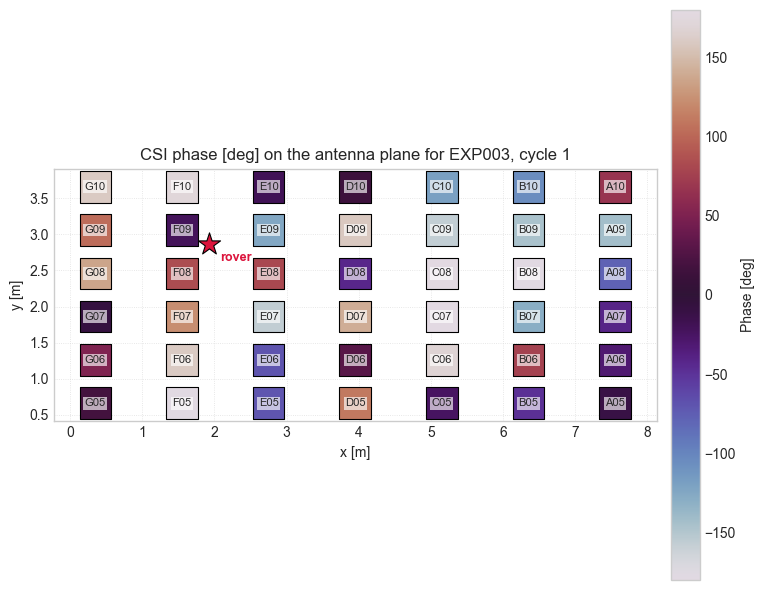

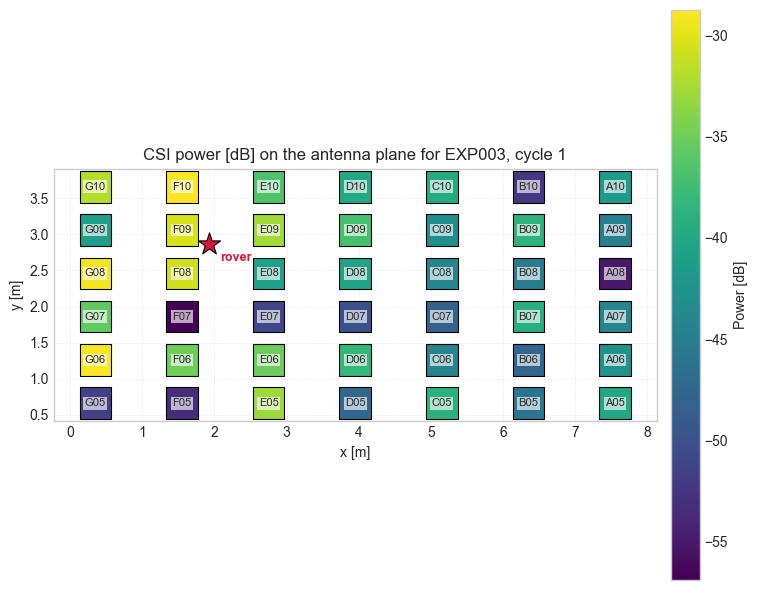

In [34]:
csi.plot_spatial_phase_snapshot(snapshot)
plt.show()

csi.plot_spatial_power_snapshot(snapshot)
plt.show()


## Use The Full Heatmaps To Choose Another Cycle

These plots show the last `HEATMAP_MAX_CYCLE_VALUES` cycle values and are useful when you want to pick a different cycle before extracting another CSI snapshot.


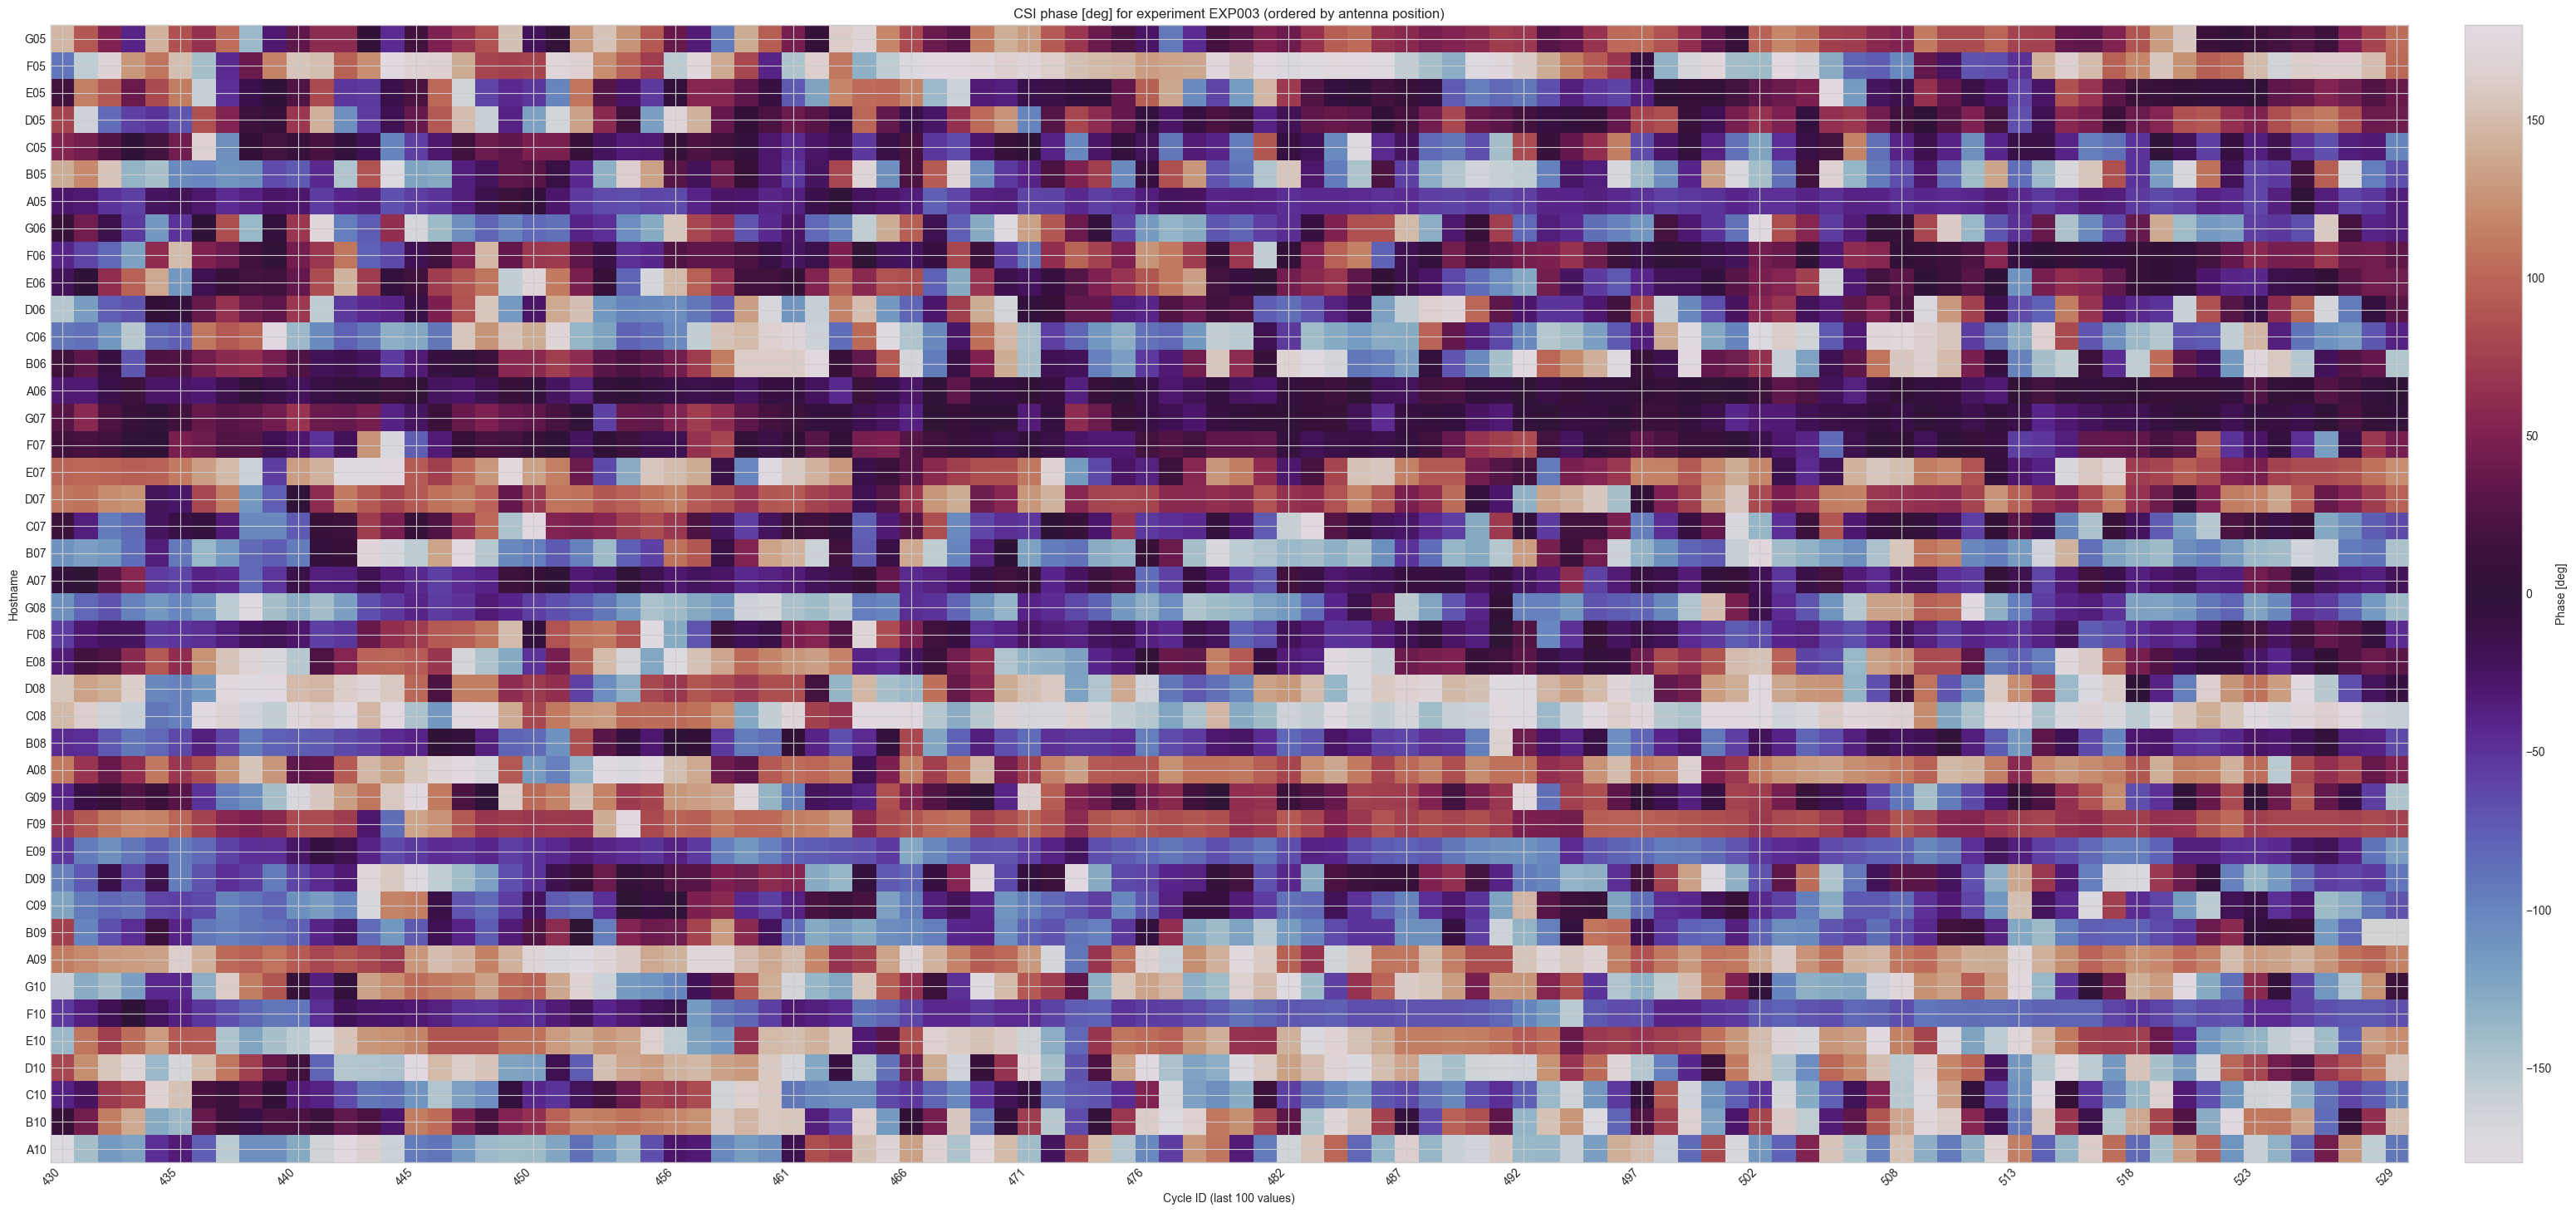

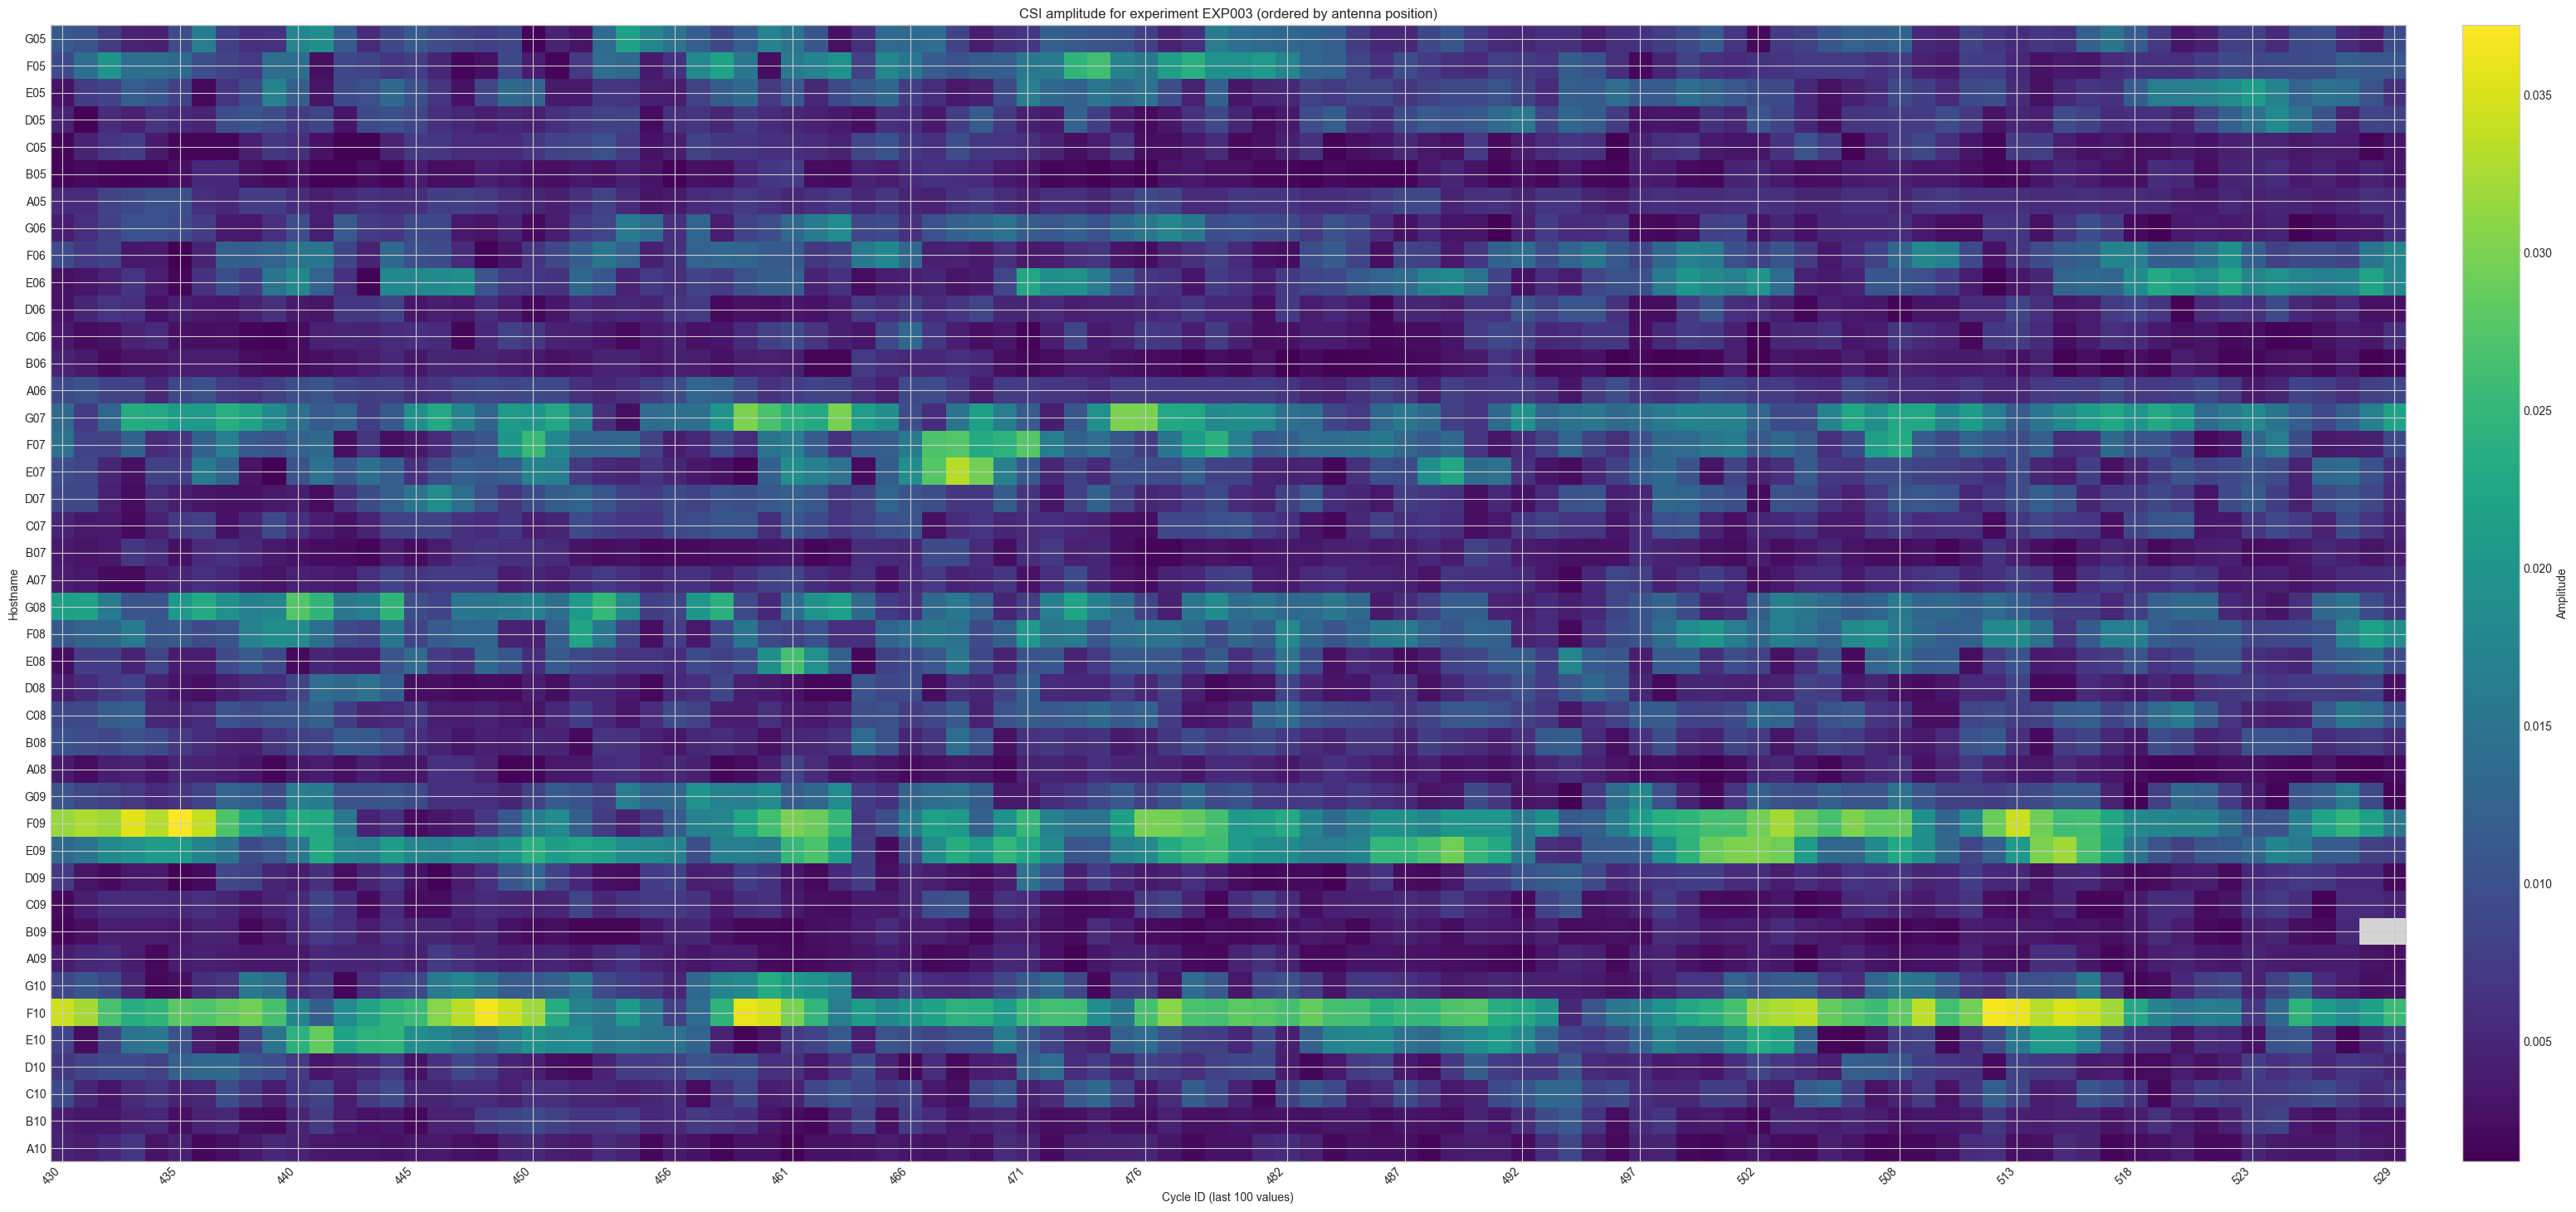

In [35]:
csi.plot_phase_heatmap(
    ds,
    EXPERIMENT_ID,
    antenna_positions=antenna_positions,
    max_cycle_values=HEATMAP_MAX_CYCLE_VALUES,
)
plt.show()

csi.plot_amplitude_heatmap(
    ds,
    EXPERIMENT_ID,
    antenna_positions=antenna_positions,
    max_cycle_values=HEATMAP_MAX_CYCLE_VALUES,
)
plt.show()
